In [1]:
import os
import sys
import argparse

import numpy as np
import matplotlib.pyplot as plt

import torch

import dolfinx
import dolfinx.fem.petsc
import ufl
from mpi4py import MPI
import basix.ufl

repo_path = os.path.abspath(os.path.join(os.getcwd(), "../../"))
sys.path.append(repo_path)

from data_generation.differential_equations import PoissonSetup1LeastSquares
from utils import load_yaml, load_pkl, load_npy, format_elapsed_time, timing, plot_complex_valued_function, plot_real_valued_function

from scifem import create_real_functionspace

import torch
import torch.nn as nn
import torch.nn.init as init
import numpy as np
from petsc4py import PETSc
import scifem

from utils import project, norm_L2, convert_petsc_mat_to_torch_sparse_coo_tensor
from typing import Optional
import pickle

from train.train_loss import SurrogateLoss
from tqdm import tqdm
from utils import project, norm_L2, convert_petsc_mat_to_torch_sparse_coo_tensor, convert_weight_to_tensor


----------------------------------------
2025-10-21 15:31:47 - Start Program
----------------------------------------


In [2]:
mesh_config_path= repo_path + "/configs/poisson_setup1/config_data/config_mesh.yaml"
function_space_config_path= repo_path + "/configs/poisson_setup1/config_data/config_function_space.yaml"
output_reduced_basis_config_path= repo_path + "/configs/poisson_setup1/config_data/config_output_reduced_basis.yaml"
train_dataset_path = repo_path + "/results/poisson_setup1/train_dataset"
test_dataset_path = repo_path + "/results/poisson_setup1/test_dataset"

mesh_args = load_yaml(mesh_config_path)
function_space_args = load_yaml(function_space_config_path)
output_reduced_basis_args = load_yaml(output_reduced_basis_config_path)
poisson_least_squares = PoissonSetup1LeastSquares(mesh_args, function_space_args)

In [3]:
p_dof = load_npy(train_dataset_path+'/p_dof.npy')
sigma_u_dof = load_npy(train_dataset_path+'/sigma_u_dof.npy')

In [4]:
print("p_dof shape: ", p_dof.shape)
print("sigma_u_dof shape: ", sigma_u_dof.shape)
# print("p_dof: ", p_dof)
# print("sigma_u_dof: ", sigma_u_dof)

p_dof shape:  (5000, 32768)
sigma_u_dof shape:  (5000, 230401)


In [5]:
mesh = poisson_least_squares.mesh
Vh = poisson_least_squares.Vh

In [6]:
dtype = torch.float64

In [7]:
pod_basis_dof = np.load(train_dataset_path+'/hdiv_h1_pod_basis_dof.npy')[:,:output_reduced_basis_args['num_basis']]
pod_coeff_labels = np.load(train_dataset_path+'/hdiv_h1_pod_coeff_labels.npy')[:,:output_reduced_basis_args['num_basis']]

In [8]:
pod_basis_dof = torch.tensor(pod_basis_dof, dtype=dtype)
pod_coeff_labels = torch.tensor(pod_coeff_labels, dtype=dtype)
quadratic_weight = torch.tensor(np.load(train_dataset_path+'/hdiv_h1_quadratic_weight.npy'), dtype=dtype)
linear_weight = torch.tensor(np.load(train_dataset_path+'/hdiv_h1_linear_weight.npy'), dtype=dtype)
bias = torch.tensor(np.load(train_dataset_path+'/hdiv_h1_bias.npy'), dtype=dtype)

In [9]:
reduced_weight_list = []
for i in range(len(quadratic_weight)):
    reduced_weight = {}
    reduced_weight['quadratic'] = quadratic_weight[i]
    reduced_weight['linear'] = linear_weight[i]
    reduced_weight['bias'] = bias[i]
    reduced_weight_list.append(reduced_weight)

In [10]:
surrogate_loss = SurrogateLoss(reduced_weight_list)

In [11]:
num_samples_for_computing_reference_surrogate_loss = 500
num_basis_list = [2**i for i in range(8)]
print("num_basis_list:", num_basis_list)
reference_surrogate_loss_record = np.zeros((len(num_basis_list), num_samples_for_computing_reference_surrogate_loss))

num_basis_list: [1, 2, 4, 8, 16, 32, 64, 128]


In [12]:
start_index = 4500

In [13]:
for i, num_basis in enumerate(num_basis_list):
    for j, sample_index in enumerate(range(start_index, start_index + num_samples_for_computing_reference_surrogate_loss)):
        reference_loss = surrogate_loss(pod_coeff_labels[sample_index], sample_index, sub_dim=num_basis)
        reference_surrogate_loss_record[i, j] = reference_loss.item()

In [14]:
avg_reference_surrogate_loss_record = np.mean(reference_surrogate_loss_record, axis=1)
max_reference_surrogate_loss_record = np.max(reference_surrogate_loss_record, axis=1)
std_reference_surrogate_loss_record = np.std(reference_surrogate_loss_record, axis=1)

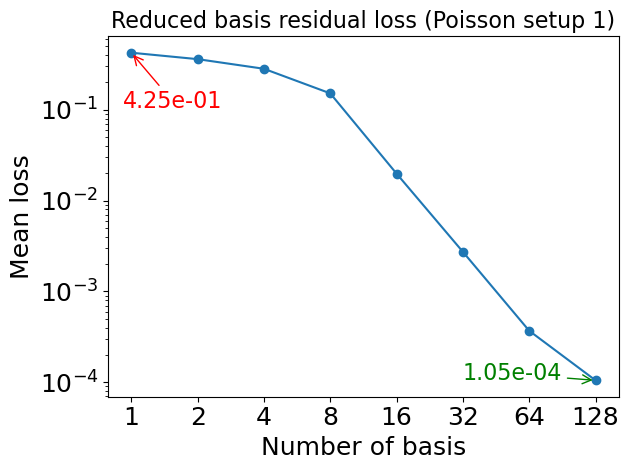

In [15]:
plt.plot(num_basis_list, avg_reference_surrogate_loss_record, marker='o')

plt.xscale('log', base=2)
plt.yscale('log', base=10)

# Set x and y ticks font size
plt.xticks(num_basis_list, num_basis_list, fontsize=18)
plt.yticks(fontsize=18)

# Find smallest and largest y values and their x positions
y_vals = np.array(avg_reference_surrogate_loss_record)
x_vals = np.array(num_basis_list)

min_idx = np.argmin(y_vals)
max_idx = np.argmax(y_vals)

# Annotate smallest value
plt.annotate(
    f"{y_vals[min_idx]:.2e}",
    (x_vals[min_idx], y_vals[min_idx]),
    textcoords="offset points",
    xytext=(-60, 0),
    ha='center',
    color='green',
    fontsize=16,
    arrowprops=dict(arrowstyle="->", color='green')
)

# Annotate largest value
plt.annotate(
    f"{y_vals[max_idx]:.2e}",
    (x_vals[max_idx], y_vals[max_idx]),
    textcoords="offset points",
    xytext=(30, -40),
    ha='center',
    color='red',
    fontsize=16,
    arrowprops=dict(arrowstyle="->", color='red')
)

plt.xlabel('Number of basis', fontsize=18)
plt.ylabel('Mean loss', fontsize=18)
plt.title('Reduced basis residual loss (Poisson setup 1)', fontsize=16)

plt.tight_layout()
# plt.savefig('reduced_basis_residual_loss_poisson_setup1.png')
plt.show()


In [16]:
print("avg_reference_surrogate_loss_record:", [f"{x:.2e}" for x in avg_reference_surrogate_loss_record])
print("std_reference_surrogate_loss_record:", [f"{x:.2e}" for x in std_reference_surrogate_loss_record])

avg_reference_surrogate_loss_record: ['4.25e-01', '3.61e-01', '2.83e-01', '1.52e-01', '1.98e-02', '2.73e-03', '3.69e-04', '1.05e-04']
std_reference_surrogate_loss_record: ['2.56e-01', '2.25e-01', '1.90e-01', '1.13e-01', '2.59e-02', '2.36e-03', '2.33e-04', '2.60e-05']


In [17]:
compute_squared_L2_norm = poisson_least_squares.compute_squared_L2_norm
compute_squared_hdiv_h1_norm = poisson_least_squares.compute_squared_hdiv_h1_norm

In [18]:
num_samples_for_computing_low_rank_approximation_error = 500

In [19]:
sigma_u_error_squared_L2_norm_record = np.zeros((len(num_basis_list), num_samples_for_computing_low_rank_approximation_error))
sigma_u_relative_error_squared_L2_norm_record = np.zeros((len(num_basis_list), num_samples_for_computing_low_rank_approximation_error))

In [20]:
sigma_u_squared_L2_norm_record = np.zeros(num_samples_for_computing_low_rank_approximation_error)
for j, sample_index in enumerate(tqdm(range(start_index, start_index + num_samples_for_computing_low_rank_approximation_error))):
    sigma_u_label_fc = dolfinx.fem.Function(Vh['sigma_u'])
    sigma_u_label_fc.x.array[:] = sigma_u_dof[sample_index]
    sigma_u_squared_L2_norm_record[j] = compute_squared_L2_norm(sigma_u_label_fc)
avg_sigma_u_squared_L2_norm = np.mean(sigma_u_squared_L2_norm_record)

100%|██████████| 500/500 [00:03<00:00, 142.76it/s]


In [21]:
for i, num_basis in enumerate(tqdm(num_basis_list)):
    low_rank_sigma_u_dof = pod_coeff_labels[start_index:start_index+num_samples_for_computing_low_rank_approximation_error, :num_basis] @ pod_basis_dof[:, :num_basis].T
    for j, sample_index in enumerate(tqdm(range(start_index, start_index + num_samples_for_computing_low_rank_approximation_error))):
        sigma_u_label_fc = dolfinx.fem.Function(Vh['sigma_u'])
        sigma_u_label_fc.x.array[:] = sigma_u_dof[sample_index]

        sigma_u_low_rank_fc = dolfinx.fem.Function(Vh['sigma_u'])
        sigma_u_low_rank_fc.x.array[:] = low_rank_sigma_u_dof[j].numpy()

        sigma_u_error_squared_L2_norm_record[i, j] = compute_squared_L2_norm(sigma_u_label_fc - sigma_u_low_rank_fc)
        sigma_u_relative_error_squared_L2_norm_record[i, j] = sigma_u_error_squared_L2_norm_record[i, j] / avg_sigma_u_squared_L2_norm

100%|██████████| 8/8 [00:44<00:00,  5.56s/it]


In [22]:
sigma_u_error_L2_bochner_norm_record = np.sqrt(np.mean(sigma_u_error_squared_L2_norm_record, axis=1))
sigma_u_relative_error_L2_bochner_norm_record = np.sqrt(np.mean(sigma_u_relative_error_squared_L2_norm_record, axis=1))

In [23]:
std_sigma_u_error_L2_norm_record = np.std(np.sqrt(sigma_u_error_squared_L2_norm_record), axis=1)
std_sigma_u_relative_error_L2_norm_record = np.std(np.sqrt(sigma_u_relative_error_squared_L2_norm_record), axis=1)

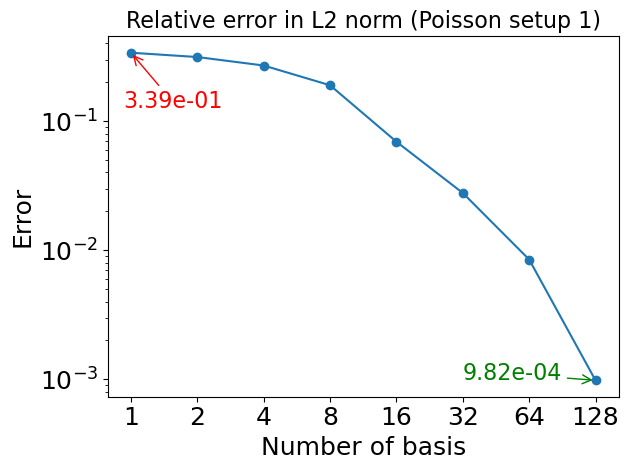

In [24]:
plt.plot(num_basis_list, sigma_u_relative_error_L2_bochner_norm_record, marker='o')

plt.xscale('log', base=2)
plt.yscale('log', base=10)
plt.xticks(num_basis_list, num_basis_list, fontsize=18)
plt.yticks(fontsize=18)

# Find smallest and largest y values and their x positions
y_vals = np.array(sigma_u_relative_error_L2_bochner_norm_record)
x_vals = np.array(num_basis_list)

min_idx = np.argmin(y_vals)
max_idx = np.argmax(y_vals)

# Annotate smallest value
plt.annotate(
    f"{y_vals[min_idx]:.2e}",
    (x_vals[min_idx], y_vals[min_idx]),
    textcoords="offset points",
    xytext=(-60, 0),
    ha='center',
    color='green',
    fontsize=16,
    arrowprops=dict(arrowstyle="->", color='green')
)

# Annotate largest value
plt.annotate(
    f"{y_vals[max_idx]:.2e}",
    (x_vals[max_idx], y_vals[max_idx]),
    textcoords="offset points", 
    xytext=(30, -40),
    ha='center',
    color='red',
    fontsize=16,
    arrowprops=dict(arrowstyle="->", color='red')
)

plt.xlabel('Number of basis', fontsize=18)
plt.ylabel('Error', fontsize=18)
plt.title('Relative error in L2 norm (Poisson setup 1)', fontsize=16)

plt.tight_layout()
# plt.savefig('relative_error_L2_norm_poisson_setup1.png')
plt.show()

In [25]:
print("sigma_u_relative_error_L2_bochner_norm_record:", [f"{x:.2e}" for x in sigma_u_relative_error_L2_bochner_norm_record])
print("std_sigma_u_relative_error_L2_norm_record:", [f"{x:.2e}" for x in std_sigma_u_relative_error_L2_norm_record])    

sigma_u_relative_error_L2_bochner_norm_record: ['3.39e-01', '3.14e-01', '2.70e-01', '1.90e-01', '6.93e-02', '2.78e-02', '8.47e-03', '9.82e-04']
std_sigma_u_relative_error_L2_norm_record: ['4.21e-02', '4.06e-02', '4.06e-02', '3.08e-02', '1.74e-02', '5.83e-03', '1.71e-03', '1.96e-04']


In [26]:
sigma_u_error_squared_hdiv_h1_norm_record = np.zeros((len(num_basis_list), num_samples_for_computing_low_rank_approximation_error))
sigma_u_relative_error_squared_hdiv_h1_norm_record = np.zeros((len(num_basis_list), num_samples_for_computing_low_rank_approximation_error))

In [27]:
sigma_u_squared_hdiv_h1_norm_record = np.zeros(num_samples_for_computing_low_rank_approximation_error)
for j, sample_index in enumerate(tqdm(range(start_index, start_index + num_samples_for_computing_low_rank_approximation_error))):
    sigma_u_label_fc = dolfinx.fem.Function(Vh['sigma_u'])
    sigma_u_label_fc.x.array[:] = sigma_u_dof[sample_index]
    sigma_label_fc = sigma_u_label_fc.sub(0).collapse()
    u_label_fc = sigma_u_label_fc.sub(1).collapse()
    sigma_u_squared_hdiv_h1_norm_record[j] = compute_squared_hdiv_h1_norm(sigma_label_fc, u_label_fc)
avg_sigma_u_squared_hdiv_h1_norm = np.mean(sigma_u_squared_hdiv_h1_norm_record)

100%|██████████| 500/500 [00:07<00:00, 68.95it/s]


In [28]:
for i, num_basis in enumerate(tqdm(num_basis_list)):
    low_rank_sigma_u_dof = pod_coeff_labels[start_index:start_index+num_samples_for_computing_low_rank_approximation_error, :num_basis] @ pod_basis_dof[:, :num_basis].T
    for j, sample_index in enumerate(tqdm(range(start_index, start_index + num_samples_for_computing_low_rank_approximation_error))):
        sigma_u_label_fc = dolfinx.fem.Function(Vh['sigma_u'])
        sigma_u_label_fc.x.array[:] = sigma_u_dof[sample_index]
        sigma_label_fc = sigma_u_label_fc.sub(0).collapse()
        u_label_fc = sigma_u_label_fc.sub(1).collapse()

        sigma_u_low_rank_fc = dolfinx.fem.Function(Vh['sigma_u'])
        sigma_u_low_rank_fc.x.array[:] = low_rank_sigma_u_dof[j].numpy()
        sigma_label_low_rank_fc = sigma_u_low_rank_fc.sub(0).collapse()
        u_label_low_rank_fc = sigma_u_low_rank_fc.sub(1).collapse()

        sigma_u_error_squared_hdiv_h1_norm_record[i, j] = compute_squared_hdiv_h1_norm(sigma_label_fc - sigma_label_low_rank_fc, u_label_fc - u_label_low_rank_fc)
        sigma_u_relative_error_squared_hdiv_h1_norm_record[i, j] = sigma_u_error_squared_hdiv_h1_norm_record[i, j] / avg_sigma_u_squared_hdiv_h1_norm

100%|██████████| 8/8 [01:52<00:00, 14.00s/it]


In [29]:
sigma_u_error_hdiv_h1_bochner_norm_record = np.sqrt(np.mean(sigma_u_error_squared_hdiv_h1_norm_record, axis=1))
sigma_u_relative_error_hdiv_h1_bochner_norm_record = np.sqrt(np.mean(sigma_u_relative_error_squared_hdiv_h1_norm_record, axis=1))

In [30]:
std_sigma_u_error_hdiv_h1_norm_record = np.std(np.sqrt(sigma_u_error_squared_hdiv_h1_norm_record), axis=1) 
std_sigma_u_relative_error_hdiv_h1_norm_record = np.std(np.sqrt(sigma_u_relative_error_squared_hdiv_h1_norm_record), axis=1)

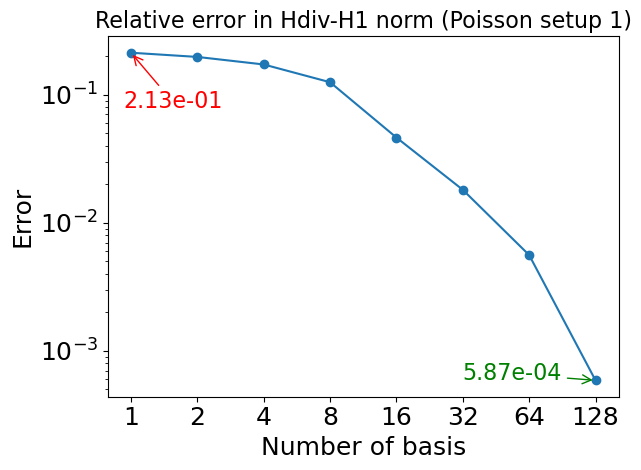

In [31]:
plt.plot(num_basis_list, sigma_u_relative_error_hdiv_h1_bochner_norm_record, marker='o')

plt.xscale('log', base=2)
plt.yscale('log', base=10)
plt.xticks(num_basis_list, num_basis_list, fontsize=18)
plt.yticks(fontsize=18)

# Find smallest and largest y values and their x positions
y_vals = np.array(sigma_u_relative_error_hdiv_h1_bochner_norm_record)
x_vals = np.array(num_basis_list)

min_idx = np.argmin(y_vals)
max_idx = np.argmax(y_vals)

# Annotate smallest value
plt.annotate(
    f"{y_vals[min_idx]:.2e}",
    (x_vals[min_idx], y_vals[min_idx]),
    textcoords="offset points",
    xytext=(-60, 0),
    ha='center',
    color='green',
    fontsize=16,
    arrowprops=dict(arrowstyle="->", color='green')
)

# Annotate largest value
plt.annotate(
    f"{y_vals[max_idx]:.2e}",
    (x_vals[max_idx], y_vals[max_idx]),
    textcoords="offset points",
    xytext=(30, -40),
    ha='center',
    color='red',
    fontsize=16,
    arrowprops=dict(arrowstyle="->", color='red')
)

plt.xlabel('Number of basis', fontsize=18)
plt.ylabel('Error',fontsize=18)
plt.title('Relative error in Hdiv-H1 norm (Poisson setup 1)', fontsize=16)

plt.tight_layout()
# plt.savefig('relative_error_hdiv_h1_norm_poisson_setup1.png')
plt.show()

In [32]:
print("sigma_u_relative_error_hdiv_h1_bochner_norm_record:", [f"{x:.2e}" for x in sigma_u_relative_error_hdiv_h1_bochner_norm_record])
print("std_sigma_u_relative_error_hdiv_h1_norm_record:", [f"{x:.2e}" for x in std_sigma_u_relative_error_hdiv_h1_norm_record])

sigma_u_relative_error_hdiv_h1_bochner_norm_record: ['2.13e-01', '1.97e-01', '1.72e-01', '1.25e-01', '4.62e-02', '1.81e-02', '5.59e-03', '5.87e-04']
std_sigma_u_relative_error_hdiv_h1_norm_record: ['2.54e-02', '2.42e-02', '2.46e-02', '2.01e-02', '1.30e-02', '3.50e-03', '1.14e-03', '1.14e-04']


In [37]:
# perturbed_reference_surrogate_loss_record = np.zeros((len(num_basis_list), num_samples_for_computing_reference_surrogate_loss))
# perturbed_sigma_u_error_squared_L2_norm_record = np.zeros((len(num_basis_list), num_samples_for_computing_low_rank_approximation_error))
# perturbed_sigma_u_relative_error_squared_L2_norm_record = np.zeros((len(num_basis_list), num_samples_for_computing_low_rank_approximation_error))
# perturbed_sigma_u_error_squared_hdiv_h1_norm_record = np.zeros((len(num_basis_list), num_samples_for_computing_low_rank_approximation_error))
# perturbed_sigma_u_relative_error_squared_hdiv_h1_norm_record = np.zeros((len(num_basis_list), num_samples_for_computing_low_rank_approximation_error))

In [38]:
# for i, num_basis in enumerate(tqdm(num_basis_list)):
#     subset_labels = pod_coeff_labels[start_index:start_index+num_samples_for_computing_low_rank_approximation_error, :num_basis]
#     noise = np.random.uniform(-1, 1, size=subset_labels.shape)
#     strength = 0.005
#     perturbed_pod_coeff_labels = subset_labels + strength * noise
#     low_rank_sigma_u_dof_purturbed = perturbed_pod_coeff_labels @ pod_basis_dof[:, :num_basis].T
#     for j, sample_index in enumerate(tqdm(range(start_index, start_index + num_samples_for_computing_low_rank_approximation_error))):
#         sigma_u_label_fc = dolfinx.fem.Function(Vh['sigma_u'])
#         sigma_u_label_fc.x.array[:] = sigma_u_dof[sample_index]
#         sigma_label_fc = sigma_u_label_fc.sub(0).collapse()
#         u_label_fc = sigma_u_label_fc.sub(1).collapse()

#         sigma_u_low_rank_fc = dolfinx.fem.Function(Vh['sigma_u'])
#         sigma_u_low_rank_fc.x.array[:] = low_rank_sigma_u_dof_purturbed[j]
#         sigma_label_low_rank_fc = sigma_u_low_rank_fc.sub(0).collapse()
#         u_label_low_rank_fc = sigma_u_low_rank_fc.sub(1).collapse()

#         perturbed_reference_loss = surrogate_loss(perturbed_pod_coeff_labels[j], sample_index, sub_dim=num_basis)
#         perturbed_reference_surrogate_loss_record[i, j] = perturbed_reference_loss.item()

#         perturbed_sigma_u_error_squared_L2_norm_record[i, j] = compute_squared_L2_norm(sigma_u_label_fc - sigma_u_low_rank_fc)
#         perturbed_sigma_u_relative_error_squared_L2_norm_record[i, j] = perturbed_sigma_u_error_squared_L2_norm_record[i, j] / avg_sigma_u_squared_L2_norm

#         perturbed_sigma_u_error_squared_hdiv_h1_norm_record[i, j] = compute_squared_hdiv_h1_norm(sigma_label_fc - sigma_label_low_rank_fc, u_label_fc - u_label_low_rank_fc)
#         perturbed_sigma_u_relative_error_squared_hdiv_h1_norm_record[i, j] = perturbed_sigma_u_error_squared_hdiv_h1_norm_record[i, j] / avg_sigma_u_squared_hdiv_h1_norm

In [39]:
# perturbed_avg_reference_surrogate_loss_record = np.mean(perturbed_reference_surrogate_loss_record, axis=1)
# perturbed_sigma_u_error_L2_bochner_norm_record = np.sqrt(np.mean(perturbed_sigma_u_error_squared_L2_norm_record, axis=1))
# perturbed_sigma_u_relative_error_L2_bochner_norm_record = np.sqrt(np.mean(perturbed_sigma_u_relative_error_squared_L2_norm_record, axis=1))
# perturbed_sigma_u_error_hdiv_h1_bochner_norm_record = np.sqrt(np.mean(perturbed_sigma_u_error_squared_hdiv_h1_norm_record, axis=1))
# perturbed_sigma_u_relative_error_hdiv_h1_bochner_norm_record = np.sqrt(np.mean(perturbed_sigma_u_relative_error_squared_hdiv_h1_norm_record, axis=1))

In [40]:
# print("perturbed_avg_reference_surrogate_loss_record:", [f"{x:.2e}" for x in perturbed_avg_reference_surrogate_loss_record])
# print("perturbed_sigma_u_relative_error_L2_bochner_norm_record:", [f"{x:.2e}" for x in perturbed_sigma_u_relative_error_L2_bochner_norm_record])    
# print("perturbed_sigma_u_relative_error_hdiv_h1_bochner_norm_record:", [f"{x:.2e}" for x in perturbed_sigma_u_relative_error_hdiv_h1_bochner_norm_record])  

In [41]:
# temp = np.load('/work/yuan/VCNO2/results/poisson_setup1/model_test_outputs/rbno_physics_loss/test/test_pred_sigma_u_dof_4096.npy')
# test_dof = np.load('/work/yuan/VCNO2/results/poisson_setup1/test_dataset/sigma_u_dof.npy')

In [42]:
# from models import ConvolutionalNN_129x129
# model_train_outputs_path = repo_path + "/results/poisson_setup1/model_train_outputs/rbno_physics_loss/test"
# num_train = 4096

In [43]:
# model = ConvolutionalNN_129x129(output_dim=num_basis, activation='leakyrelu', init_func='xavier_uniform')
# model.load_state_dict(torch.load(os.path.join(model_train_outputs_path, f"best_model_params_{num_train}.pth")))


# latest_model = ConvolutionalNN_129x129(output_dim=num_basis, activation='leakyrelu', init_func='xavier_uniform')
# latest_model.load_state_dict(torch.load(os.path.join(model_train_outputs_path, f"latest_model_params_{num_train}.pth")))

# # %%
# num_test = 500

# test_p_dof = load_npy(test_dataset_path+'/p_dof.npy')[:num_test]
# test_sigma_u_dof = load_npy(test_dataset_path+'/sigma_u_dof.npy')[:num_test]
# test_p_vertex_values = load_npy(test_dataset_path+'/p_vertex_values.npy')[:num_test]

In [44]:
# num_x, num_y = 128, 128
# torch_dtype = {
#     'float32': torch.float32,
#     'float64': torch.float64
# }

In [45]:
# # %%
# test_image_p_vertex_values = np.zeros((num_test, 1, mesh_args['num_y']+1, mesh_args['num_x']+1))
# for i in tqdm(range(num_test)):
#     test_image_p_vertex_values[i,0,:,:] = test_p_vertex_values[i].reshape(num_x+1, num_y+1).T

# # %%
# test_p_vertex_values_tensor = torch.tensor(test_image_p_vertex_values, dtype=torch_dtype['float32'])

# # %%
# test_pod_coeff_pred  = model(test_p_vertex_values_tensor)
# test_pod_coeff_pred = test_pod_coeff_pred.cpu().detach()
# test_pred = test_pod_coeff_pred.to(torch.float64) @ pod_basis_dof.T
# test_pred = test_pred.numpy()

In [46]:
# num_train_for_test = 500
# p_vertex_values = load_npy(train_dataset_path+'/p_vertex_values.npy')[:num_train_for_test]

In [47]:
# image_p_vertex_values = np.zeros((num_train_for_test, 1, mesh_args['num_y']+1, mesh_args['num_x']+1))
# for i in tqdm(range(num_train_for_test)):
#     image_p_vertex_values[i,0,:,:] = p_vertex_values[i].reshape(num_x+1, num_y+1).T
 
# # %%
# p_vertex_values_tensor = torch.tensor(image_p_vertex_values, dtype=torch_dtype['float32'])

# # %%
# pod_coeff_pred  = model(p_vertex_values_tensor)
# pod_coeff_pred = pod_coeff_pred.cpu().detach()
# pred = pod_coeff_pred.to(torch.float64) @ pod_basis_dof.T
# pred = pred.numpy()

In [48]:
# pod_coeff_pred = pod_coeff_pred.to(torch.float64)

In [49]:
# test_pod_coeff_pred = test_pod_coeff_pred.to(torch.float64)

In [50]:
# sample_index = 0
# print(f'reduced basis reference loss: {surrogate_loss(pod_coeff_labels[sample_index], sample_index, sub_dim=num_basis).item()}')
# print(f'reduced basis prediction loss: {surrogate_loss(pod_coeff_pred[sample_index], sample_index, sub_dim=num_basis).item()} ')

# label_sigma_u_fc = dolfinx.fem.Function(Vh['sigma_u'])
# label_sigma_u_fc.x.array[:] = pod_coeff_labels[sample_index] @ pod_basis_dof.T
# label_sigma_fc = label_sigma_u_fc.sub(0).collapse()
# u_label_fc = label_sigma_u_fc.sub(1).collapse()

# pred_sigma_u_fc = dolfinx.fem.Function(Vh['sigma_u'])
# pred_sigma_u_fc.x.array[:] = pod_coeff_pred[sample_index] @ pod_basis_dof.T
# pred_sigma_fc = pred_sigma_u_fc.sub(0).collapse()
# u_pred_fc = pred_sigma_u_fc.sub(1).collapse()

# print(f'relative L2 error: {np.sqrt(compute_squared_L2_norm(pred_sigma_u_fc - label_sigma_u_fc)/compute_squared_L2_norm(label_sigma_u_fc))}')
# print(f'L2 error: {np.sqrt(compute_squared_L2_norm(pred_sigma_u_fc - label_sigma_u_fc))}')
# print(f'relative Hdiv-H1 error: {np.sqrt(compute_squared_hdiv_h1_norm(pred_sigma_fc - label_sigma_fc, u_pred_fc - u_label_fc)/compute_squared_hdiv_h1_norm(label_sigma_fc, u_label_fc))}')
# print(f'Hdiv-H1 error: {np.sqrt(compute_squared_hdiv_h1_norm(pred_sigma_fc - label_sigma_fc, u_pred_fc - u_label_fc))}')

In [51]:
# label_sigma_u_fc = dolfinx.fem.Function(Vh['sigma_u'])
# label_sigma_u_fc.x.array[:] = sigma_u_dof[sample_index]
# label_sigma_fc = label_sigma_u_fc.sub(0).collapse()
# label_u_fc = label_sigma_u_fc.sub(1).collapse()

# pred_sigma_u_fc = dolfinx.fem.Function(Vh['sigma_u'])
# pred_sigma_u_fc.x.array[:] = pod_coeff_pred[sample_index] @ pod_basis_dof.T
# pred_sigma_fc = pred_sigma_u_fc.sub(0).collapse()
# u_pred_fc = pred_sigma_u_fc.sub(1).collapse()

# print(f'relative L2 error: {np.sqrt(compute_squared_L2_norm(pred_sigma_u_fc - label_sigma_u_fc)/compute_squared_L2_norm(label_sigma_u_fc))}')
# print(f'L2 error: {np.sqrt(compute_squared_L2_norm(pred_sigma_u_fc - label_sigma_u_fc))}')
# print(f'relative Hdiv-H1 error: {np.sqrt(compute_squared_hdiv_h1_norm(pred_sigma_fc - label_sigma_fc, u_pred_fc - label_u_fc)/compute_squared_hdiv_h1_norm(label_sigma_fc, label_u_fc))}')
# print(f'Hdiv-H1 error: {np.sqrt(compute_squared_hdiv_h1_norm(pred_sigma_fc - label_sigma_fc, u_pred_fc - label_u_fc))}')

In [52]:
# test_pod_coeff_label = load_npy(test_dataset_path+'/hdiv_h1_pod_coeff_labels.npy')[:num_test]
# test_pod_coeff_labels = torch.tensor(test_pod_coeff_label, dtype=dtype)
# test_quadratic_weight = torch.tensor(np.load(test_dataset_path+'/hdiv_h1_quadratic_weight.npy'), dtype=dtype)
# test_linear_weight = torch.tensor(np.load(test_dataset_path+'/hdiv_h1_linear_weight.npy'), dtype=dtype)
# test_bias = torch.tensor(np.load(test_dataset_path+'/hdiv_h1_bias.npy'), dtype=dtype)

In [53]:
# test_reduced_weight_list = []
# for i in range(len(test_quadratic_weight)):
#     reduced_weight = {}
#     reduced_weight['quadratic'] = test_quadratic_weight[i]
#     reduced_weight['linear'] = test_linear_weight[i]
#     reduced_weight['bias'] = test_bias[i]
#     test_reduced_weight_list.append(reduced_weight)

In [54]:
# test_surrogate_loss = SurrogateLoss(test_reduced_weight_list)

In [55]:
# sample_index = 3
# print(f'reduced basis reference loss: {test_surrogate_loss(test_pod_coeff_labels[sample_index], sample_index, sub_dim=num_basis)}')
# print(f'reduced basis prediction loss: {test_surrogate_loss(test_pod_coeff_pred[sample_index], sample_index, sub_dim=num_basis)} ')

In [56]:
# label_sigma_u_fc = dolfinx.fem.Function(Vh['sigma_u'])
# label_sigma_u_fc.x.array[:] = test_sigma_u_dof[sample_index]

In [57]:
# test_sigma_u_fc = dolfinx.fem.Function(Vh['sigma_u'])
# test_sigma_u_fc.x.array[:] = test_pred[sample_index]
# np.sqrt(compute_squared_L2_norm(test_sigma_u_fc - label_sigma_u_fc)/compute_squared_L2_norm(label_sigma_u_fc))

In [58]:
# low_rank_dof_label = test_pod_coeff_label @ (pod_basis_dof.T).numpy()
# float32_test_pod_coeff_label = test_pod_coeff_label.astype(np.float32)
# reconstructed_float64_test_pod_coeff_label = float32_test_pod_coeff_label.astype(np.float64)
# low_precision_low_rank_dof_label = reconstructed_float64_test_pod_coeff_label @ (pod_basis_dof.T).numpy()

In [59]:
# low_rank_sigma_u_fc = dolfinx.fem.Function(Vh['sigma_u'])
# low_rank_sigma_u_fc.x.array[:] = low_rank_dof_label[sample_index]
# low_rank_sigma_fc = low_rank_sigma_u_fc.sub(0).collapse()
# low_rank_u_fc = low_rank_sigma_u_fc.sub(1).collapse()
# np.sqrt(compute_squared_L2_norm(low_rank_sigma_u_fc - label_sigma_u_fc)/compute_squared_L2_norm(label_sigma_u_fc))

In [60]:
# low_precision_low_rank_sigma_u_fc = dolfinx.fem.Function(Vh['sigma_u'])
# low_precision_low_rank_sigma_u_fc.x.array[:] = low_precision_low_rank_dof_label[sample_index]
# np.sqrt(compute_squared_L2_norm(low_precision_low_rank_sigma_u_fc - label_sigma_u_fc)/compute_squared_L2_norm(label_sigma_u_fc))

In [61]:
# np.sqrt(compute_squared_L2_norm(low_rank_sigma_u_fc - label_sigma_u_fc)/compute_squared_L2_norm(label_sigma_u_fc))

In [62]:
new_num_basis_list = [2, 8, 32, 128]

In [71]:
sample_index = start_index + 10

for i, num_basis in enumerate(new_num_basis_list):
    label_sigma_u_fc = dolfinx.fem.Function(Vh['sigma_u'])
    label_sigma_u_fc.x.array[:] = sigma_u_dof[sample_index]
    label_sigma_fc = label_sigma_u_fc.sub(0).collapse()
    label_u_fc = label_sigma_u_fc.sub(1).collapse()
 
    low_rank_sigma_u_fc = dolfinx.fem.Function(Vh['sigma_u'])
    low_rank_sigma_u_fc.x.array[:] = pod_coeff_labels[sample_index, :num_basis] @ pod_basis_dof[:, :num_basis].T
    low_rank_sigma_fc = low_rank_sigma_u_fc.sub(0).collapse()
    low_rank_u_fc = low_rank_sigma_u_fc.sub(1).collapse()

    print("")
    print(f'num_basis: {num_basis}')
    squared_hdiv_h1_error = compute_squared_hdiv_h1_norm(low_rank_sigma_fc - label_sigma_fc, low_rank_u_fc - label_u_fc)

    print(f'squared Hdiv-H1 error: {squared_hdiv_h1_error:.2e}')


    p_fc = dolfinx.fem.Function(Vh['p'])  
    p_fc.x.array[:] = p_dof[sample_index]
    weight = poisson_least_squares.compute_weight(p_fc)
    weight_tensor = convert_weight_to_tensor(weight, dtype=torch.float64)

    y = pod_coeff_labels[sample_index, :num_basis] @ pod_basis_dof[:, :num_basis].T
    y = torch.tensor(y, dtype=torch.float64)
    low_rank_reference_loss = torch.dot(y, weight_tensor['A00'] @ y) + 2*torch.dot(y, weight_tensor['A01'])  + weight_tensor['A11']
    print(f'low rank reference loss: {low_rank_reference_loss.item()}')

    
    y = sigma_u_dof[sample_index]
    y = torch.tensor(y, dtype=torch.float64)
    label_reference_loss = torch.dot(y, weight_tensor['A00'] @ y) + 2*torch.dot(y, weight_tensor['A01'])  + weight_tensor['A11']
    print(f'label reference loss: {label_reference_loss.item()}')

    print(f'gap between low rank reference loss and label reference loss: {(low_rank_reference_loss.item() - label_reference_loss.item()):.2e}')


num_basis: 2
squared Hdiv-H1 error: 6.02e-02
low rank reference loss: 0.1256261452882408
label reference loss: 0.0001403023911035195
gap between low rank reference loss and label reference loss: 1.25e-01

num_basis: 8
squared Hdiv-H1 error: 1.37e-02
low rank reference loss: 0.023811680485284814
label reference loss: 0.0001403023911035195
gap between low rank reference loss and label reference loss: 2.37e-02

num_basis: 32
squared Hdiv-H1 error: 5.81e-04
low rank reference loss: 0.001850807005996602
label reference loss: 0.0001403023911035195
gap between low rank reference loss and label reference loss: 1.71e-03

num_basis: 128
squared Hdiv-H1 error: 5.68e-07
low rank reference loss: 0.00014089460545951837
label reference loss: 0.0001403023911035195
gap between low rank reference loss and label reference loss: 5.92e-07


In [ ]:
# pred_sigma_u_fc = dolfinx.fem.Function(Vh['sigma_u'])
# pred_sigma_u_fc.x.array[:] = test_pred[sample_index]
# pred_sigma_fc = pred_sigma_u_fc.sub(0).collapse()
# pred_u_fc = pred_sigma_u_fc.sub(1).collapse()

# label_sigma_u_fc = dolfinx.fem.Function(Vh['sigma_u'])
# label_sigma_u_fc.x.array[:] = test_sigma_u_dof[sample_index]
# label_sigma_fc = label_sigma_u_fc.sub(0).collapse()
# label_u_fc = label_sigma_u_fc.sub(1).collapse()

# print(f'relative L2 error {np.sqrt(compute_squared_L2_norm(pred_sigma_u_fc - label_sigma_u_fc)/compute_squared_L2_norm(label_sigma_u_fc))}')
# print(f'relative Hdiv-H1 error {np.sqrt(compute_squared_hdiv_h1_norm(pred_sigma_fc - label_sigma_fc, pred_u_fc - label_u_fc)/compute_squared_hdiv_h1_norm(label_sigma_fc, label_u_fc))}')
# print(f'L2 error: {np.sqrt(compute_squared_L2_norm(pred_sigma_u_fc - label_sigma_u_fc))}')
# print(f'Hdiv-H1 error: {np.sqrt(compute_squared_hdiv_h1_norm(pred_sigma_fc - label_sigma_fc, pred_u_fc - label_u_fc))}')
# print(f'squared L2 error: {compute_squared_L2_norm(pred_sigma_u_fc - label_sigma_u_fc)}')
# print(f'squared Hdiv-H1 error: {compute_squared_hdiv_h1_norm(pred_sigma_fc - label_sigma_fc, pred_u_fc - label_u_fc)}')

relative L2 error 0.03982710223403568
relative Hdiv-H1 error 0.030211296362012145
L2 error: 0.020794024383493634
Hdiv-H1 error: 0.03748443933433563
squared L2 error: 0.00043239145006132774
squared Hdiv-H1 error: 0.001405083192209488


In [ ]:
# p_fc = dolfinx.fem.Function(Vh['p'])  
# p_fc.x.array[:] = test_p_dof[sample_index]
# weight = poisson_least_squares.compute_weight(p_fc)
# weight_tensor = convert_weight_to_tensor(weight, dtype=torch_dtype['float64'])

# y = test_pred[sample_index]
# y = torch.tensor(y, dtype=torch_dtype['float64'])
# pred_reference_loss = torch.dot(y, weight_tensor['A00'] @ y) + 2*torch.dot(y, weight_tensor['A01'])  + weight_tensor['A11']
# print(f'pred reference loss: {pred_reference_loss.item()}')

# y = test_sigma_u_dof[sample_index]
# y = torch.tensor(y, dtype=torch_dtype['float64'])
# label_reference_loss = torch.dot(y, weight_tensor['A00'] @ y) + 2*torch.dot(y, weight_tensor['A01'])  + weight_tensor['A11']
# print(f'label reference loss: {reference_loss.item()}')

pred reference loss: 0.000530520639742571
label reference loss: 0.00015499234675853124


In [ ]:
# print(pred_reference_loss - label_reference_loss)
# print(f'sqrt(error/loss): {np.sqrt(compute_squared_hdiv_h1_norm(pred_sigma_fc - label_sigma_fc, pred_u_fc - label_u_fc) / pred_reference_loss)}')

tensor(0.0004, dtype=torch.float64)
sqrt(error/loss): 1.6274208548474574
